# Task 1 — Final Training, Evaluation and Judgement

Which article type does this image show, and when should a person check the answer?
This notebook follows the **plain CNN already chosen from development results**. It brings the final training, saved evaluation and team handoff into one story.

**Default Run All verifies and reads saved work.** It does not train, run inference, open raw labels or write predictions. Missing or changed evidence stops replay. The optional execution controls below can run missing stages in their fixed order.

Read: [purpose](#purpose) → [model choice](#choice) → [fixed recipe](#recipe) → [training](#training) → [blind predictions](#blind) → [scoring](#scoring) → [main results](#scores) → [class errors](#errors) → [photo quality](#photos) → [judgement](#judgement) → [export](#export) → [references](#references).

The full model search stays in [Task 1 development](02_task1_article_type.ipynb).

<a id="purpose"></a>
## 1. Purpose and how to use this notebook

There are three questions: does the fixed model work on the saved holdout, which classes and image conditions cause failures, and what can the team safely claim about its use?

Leave both controls `False` to read completed results. Set `RUN_MISSING_STAGES=True` only when deliberately completing missing work. A missing scoring stage also needs `UNLOCK_HOLDOUT_SCORING=True`. Completed stages are checked and reused. Failed or partial attempts stop for inspection; do not delete receipts to try different settings on holdout.

Use the repository `.venv` kernel. Replay needs the saved model package, evidence and files checked by the audit. CUDA is needed only for new local training. The same canonical split, `data/processed/splits.csv`, is used throughout. Each real training run is recorded in `results/runs.csv`.

In [1]:
RUN_MISSING_STAGES = False
UNLOCK_HOLDOUT_SCORING = False

In [2]:
import json
import os
import sys
from pathlib import Path

detected_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p / "src/fashion").is_dir() and (p / "pyproject.toml").is_file()), None)
PROJECT_ROOT = (Path(os.environ["FASHION_PROJECT_ROOT"]).resolve()
                if os.environ.get("FASHION_PROJECT_ROOT") else detected_root)
if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook inside the MLA2 repository.")
os.environ["FASHION_PROJECT_ROOT"] = str(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import Image, Markdown, display
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")
from fashion.task1.refit import run_task1_refit, load_verified_task1_refit_manifest
from fashion.task1.final_evaluation_runner import (
    predict_holdout, score_holdout, predict_test, audit_final_evaluation,
)

EVIDENCE_DIR = PROJECT_ROOT / "results/evidence/task1/final_evaluation"
DEV_DIR = PROJECT_ROOT / "results/evidence/task1"
contract = json.loads((PROJECT_ROOT / "configs/task1/final_evaluation.json").read_text())
pd.set_option("display.max_columns", 12)
pd.set_option("display.max_colwidth", 65)
print("Mode:", "complete missing stages" if RUN_MISSING_STAGES else "read and verify")
print("Project:", PROJECT_ROOT)
display(pd.DataFrame([
    {"stage": name, "saved receipt": path.is_file()}
    for name, path in [
        ("refit", PROJECT_ROOT / "models/task1_article_type.manifest.json"),
        ("blind prediction", EVIDENCE_DIR / "prediction_receipt.json"),
        ("holdout scoring", EVIDENCE_DIR / "evaluation_manifest.json"),
        ("official export", EVIDENCE_DIR / "test_prediction_receipt.json"),
    ]
]))

Mode: read and verify
Project: C:\Users\Khoa\Documents\MLA2


,stage,saved receipt
0,refit,True
1,blind prediction,True
2,holdout scoring,True
3,official export,True


A saved receipt means a stage has a record; it is **not yet proof that its files match**. The checks later verify file fingerprints and recalculate scores from saved predictions. An absent official export can remain pending during replay; missing refit or evaluation evidence stops the report.

| Term | Simple meaning | How to use it |
|---|---|---|
| Refit | Train the chosen recipe again on all development images | A new final fit, not another validation fold |
| OOF | Predictions made by fold models that did not train on those products | Development evidence used for model choice |
| Precision / recall | How often a predicted label is right / how many true examples of a label are found | Explain false alarms and missed cases |
| F1 / macro-F1 | Balance precision and recall / average F1 equally over all 124 labels | Rare labels count as much as common ones |
| Support | Number of true examples behind a score | A small count means weaker evidence |
| SHA-256 | A file fingerprint | Matching bytes establish identity, not model quality |

<a id="choice"></a>
## 2. Why the plain CNN was chosen

**Question: which tested method best met the declared goal?** The goal was macro-F1 across 124 article types. Development has 32,773 images, with class sizes ranging from 1 to 5,748. A method that mostly learns common labels can look good on accuracy and still fail many smaller classes.

The table gives the mean and sample standard deviation across the same five folds. These are **development scores**, not holdout results. HOG measures edge and shape patterns; the CNN learns its own image features from scratch.

In [3]:
cnn_comparison = pd.read_csv(DEV_DIR / "comparison.csv", keep_default_na=False)
classical_comparison = pd.read_csv(DEV_DIR / "classical_comparison.csv", keep_default_na=False)
comparison = pd.concat([cnn_comparison, classical_comparison], ignore_index=True)
display(comparison[["candidate_id", "macro_f1_mean", "macro_f1_std",
                    "top1_accuracy_mean", "top5_accuracy_mean"]]
        .sort_values("macro_f1_mean", ascending=False).round(4))

,candidate_id,macro_f1_mean,macro_f1_std,top1_accuracy_mean,top5_accuracy_mean
0,task1_cnn_no_aug_unweighted_v1,0.5315,0.0331,0.8422,0.9780
1,task1_cnn_mild_aug_unweighted_v1,0.5218,0.0158,0.8429,0.9809
3,task1_gray_hog_ppc10_v1-knn-k3-distance,0.5023,0.0140,0.7955,0.8952
4,task1_gray_hog_ppc10_v1-linear-svm-c0.1-balanced,0.4889,0.0165,0.7765,0.9446
2,task1_cnn_mild_aug_balanced_weighted_v1,0.4564,0.0181,0.6915,0.9525


The plain CNN leads at **0.5315 macro-F1**, followed by mild augmentation at 0.5218, HOG k-NN at 0.5023, HOG SVM at 0.4889, and the class-weighted CNN at 0.4564. Learned image features helped on this task, but a wider model search would be needed to claim that CNNs always beat hand-built features.

Mild augmentation roughly halves the observed fold spread, from 0.0331 to 0.0158. That is a useful trade-off, but the higher primary score supports keeping the plain CNN. Strong weighting did not rescue rare labels enough to offset its wider loss in quality. The development notebook explains these experiments and their failures in full.

The choice was fixed on 9 September 2026 **before Task 1 holdout scoring**. A 0.0097 mean advantage on these folds is not proof of a reliable advantage across training seeds. The later holdout results below do not reopen this choice.

<a id="recipe"></a>
## 3. The fixed final recipe

**Question: what exactly was fixed before the holdout was scored?** The final fit uses the plain CNN, unweighted cross-entropy, seed 2753 and 20 epochs. Adam and OneCycleLR use the saved settings below. No validation pass, early stopping or best-fold checkpoint is used in the refit.

Images are converted to RGB and resized with padding to a 60-pixel-wide by 80-pixel-high canvas. Normalization is fitted on development images only. There is no random augmentation in the chosen model. The final package carries these settings so the app uses the same input preparation.

In [4]:
display(pd.DataFrame([contract["refit"]]).T.rename(columns={0: "fixed value"}))
histories = pd.read_csv(DEV_DIR / "cnn_learning_histories.csv")
selected_histories = histories.loc[histories.candidate_id.eq(contract["candidate_id"])]
epoch_rows = []
for fold, frame in selected_histories.groupby("fold"):
    best = frame.loc[frame.macro_f1.idxmax()]
    last = frame.loc[frame.epoch.eq(20)].iloc[0]
    epoch_rows.append({"fold": int(fold), "best epoch": int(best.epoch),
                       "best F1": best.macro_f1, "epoch 20 F1": last.macro_f1})
epoch_review = pd.DataFrame(epoch_rows)
assert len(epoch_review) == 5 and contract["refit"]["epochs"] == 20
display(epoch_review.round(4))
display(Markdown(f"Mean selected-checkpoint F1: **{epoch_review['best F1'].mean():.4f}**; "
                 f"mean epoch-20 F1: **{epoch_review['epoch 20 F1'].mean():.4f}**; "
                 f"difference: **{(epoch_review['best F1'] - epoch_review['epoch 20 F1']).mean():.4f}**."))

,fixed value
augmentation_used,False
batch_size,128
candidate_id,task1_cnn_no_aug_unweighted_v1
checkpoint_rule,fixed_last_epoch
epochs,20
grad_clip_norm,1.0
loss_id,cross_entropy_unweighted_v1
max_lr,0.001
model_family,task1_small_cnn_v1
normalization_scope,development_only


,fold,best epoch,best F1,epoch 20 F1
0,0,20,0.4981,0.4981
1,1,19,0.5195,0.5186
2,2,18,0.5176,0.5148
3,3,19,0.5370,0.5345
4,4,20,0.5852,0.5852


Mean selected-checkpoint F1: **0.5315**; mean epoch-20 F1: **0.5302**; difference: **0.0012**.

The best fold epochs are **20, 19, 18, 19, 20**. Their median is 19, but shortening the run would change the tested learning-rate schedule. Keeping epoch 20 preserves that schedule for only a small observed development-score difference.

This supports a reasonable fixed budget; it does not establish an optimal budget. All five best epochs are near the end, but that alone does not prove that extra training would help. The final checkpoint is the last epoch by rule, not the epoch that later looks best on holdout.

<a id="training"></a>
## 4. Final training and its learning curve

**Question: did the agreed fit complete?** The next stage verifies the saved model manifest, bundle, history and matching registry row. If there is no manifest, default replay stops. Only explicit execution mode may start a new refit, and the existing helper rejects partial or failed work.

The local execution path needs CUDA for new training. Reading a completed model does not need a GPU. This is the only stage allowed to add a final training row to `results/runs.csv`.

In [5]:
model_manifest_path = PROJECT_ROOT / "models/task1_article_type.manifest.json"
if not model_manifest_path.is_file():
    if not RUN_MISSING_STAGES:
        raise FileNotFoundError("Final refit missing. Set RUN_MISSING_STAGES=True only to deliberately run missing stages.")
    if not torch.cuda.is_available():
        raise RuntimeError("New local training needs CUDA. Select the repository .venv GPU kernel.")
    run_task1_refit(project_root=PROJECT_ROOT, mode="run_or_load")
model_manifest = load_verified_task1_refit_manifest(
    model_manifest_path, project_root=PROJECT_ROOT,
    registry_path=PROJECT_ROOT / "results/runs.csv",
)
print("Final refit: verified existing model and registry binding.")

Final refit: verified existing model and registry binding.


,0
candidate_id,task1_cnn_no_aug_unweighted_v1
scratch,True
final_epoch,20
development_rows,32773
run_id,task1-cnn-task1_cnn_no_aug_unweighted_v1-final-refit-fall-s27...


,epoch,train_loss,train_samples,learning_rate
0,1,3.436021,32773,0.000104
19,20,0.018784,32773,0.000000


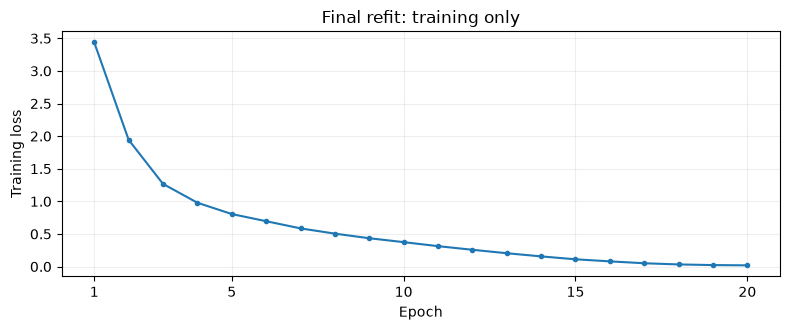

In [6]:
history = pd.read_csv(PROJECT_ROOT / model_manifest["history"]["path"])
assert history.epoch.tolist() == list(range(1, 21))
assert history.train_samples.eq(32773).all()
display(pd.DataFrame([{key: model_manifest[key] for key in
                      ["candidate_id", "scratch", "final_epoch", "development_rows", "run_id"]}]).T)
display(history.iloc[[0, -1]].round(6))
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(history.epoch, history.train_loss, marker="o", markersize=3)
ax.set(xlabel="Epoch", ylabel="Training loss", title="Final refit: training only")
ax.set_xticks([1, 5, 10, 15, 20])
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()

The curve shows how well the model fits the images it sees during training. Loss falls from **3.4360 to 0.0188**. Falling loss means the optimizer learned to assign more probability to the training labels. The history also confirms that all 32,773 development images were used in every one of the 20 epochs.

There is deliberately **no validation or holdout line**. A low training loss cannot establish performance on new images. Development OOF results justified the recipe; the fixed holdout below evaluates the resulting final fit. A successful file audit proves that we are discussing the intended model, not that every prediction is correct.

<a id="blind"></a>
## 5. Freeze and blind prediction

**Question: were predictions fixed before labels entered scoring?** The prediction stage stores all 124 probabilities for each of 5,778 holdout images, together with the fixed JPEG, brightness and blur conditions. It excludes the 61 quarantine rows. Its input view does not read raw holdout labels.

The freeze binds the model, code, input files, class order and recipe to file fingerprints. The later unlock receipt points back to the saved prediction receipt. Completed prediction files are verified during scoring/audit; a receipt's presence alone is not enough.

In [7]:
if not (EVIDENCE_DIR / "prediction_receipt.json").is_file():
    if not RUN_MISSING_STAGES:
        raise FileNotFoundError("Blind predictions missing. Set RUN_MISSING_STAGES=True to deliberately complete this stage.")
    predict_holdout(PROJECT_ROOT)
print("Blind prediction receipt found; the next audit verifies its contents and hashes.")

Blind prediction receipt found; the next audit verifies its contents and hashes.


This order reduces the chance of changing predictions after seeing which images were wrong. It is a record of the Task 1 process, not a claim that nobody in the group had seen this shared holdout: Task 2 and Task 3 had already used it for their targets.

Keep that distinction in the report. The test is independent of Task 1 model selection, within the saved process, but it is still a **same-source catalogue holdout**. It cannot prove performance on another retailer or on customer phone photos.

<a id="scoring"></a>
## 6. One-time scoring and verification

**Question: which saved outputs were scored, and was coverage complete?** If scoring is missing, execution needs the separate unlock control. That stage opens protected labels once and scores the already-fixed predictions. Replay only reads the saved scored rows and recomputes their metrics.

No model, epoch, calibration setting or review threshold can be selected here. A changed file causes the shared audit to fail rather than silently accept a different result.

In [8]:
if not (EVIDENCE_DIR / "evaluation_manifest.json").is_file():
    if not RUN_MISSING_STAGES:
        raise FileNotFoundError("Holdout scoring missing. Set RUN_MISSING_STAGES=True only for deliberate execution.")
    if not UNLOCK_HOLDOUT_SCORING:
        raise RuntimeError("Missing scoring requires UNLOCK_HOLDOUT_SCORING=True after the model and blind predictions are fixed.")
    score_holdout(PROJECT_ROOT, evaluation_unlocked=True)
evidence = audit_final_evaluation(PROJECT_ROOT)
print("Saved evaluation: hashes and scores verified. This audit ran no model.")

Saved evaluation: hashes and scores verified. This audit ran no model.


In [9]:
tables = evidence["tables"]
freeze = evidence["freeze"]
unlock_record = evidence["evaluation_manifest"]["unlock_receipt"]
unlock = json.loads((PROJECT_ROOT / unlock_record["path"]).read_text())
display(pd.DataFrame([{
    "holdout rows": len(tables["scored_rows"]),
    "unique IDs": tables["scored_rows"].id.nunique(),
    "fixed labels": len(freeze["class_names"]),
    "excluded quarantine": contract["expected_rows"]["quarantine"],
    "freeze created": freeze["created_at"],
    "scoring completed": evidence["evaluation_manifest"]["completed_at"],
}]))
display(pd.DataFrame([unlock]).T)

,holdout rows,unique IDs,fixed labels,excluded quarantine,freeze created,scoring completed
0,5778,5778,124,61,2026-09-09T03:16:44.394418+00:00,2026-09-09T03:21:06.404372+00:00


,0
access,shared protected loader joins all target columns; scoring use...
prediction_receipt,{'path': 'results/evidence/task1/final_evaluation/prediction_...
prior_access,Other targets have already used the shared holdout. Task 1 se...
target,articleType
unlocked_at,2026-09-09T03:20:59.747049+00:00


The audit checks the exact saved IDs and order, probability columns, file fingerprints and score tables. Full coverage prevents a score from looking better simply because difficult images were dropped. The fixed metric retains all 124 labels, including zeros for labels absent from this sample.

The receipt shows when labels were unlocked; it does not turn this dataset into a new domain.

<a id="scores"></a>
## 7. Main results

**Does the development result carry over?**

Read macro-F1 first, then accuracy and Top-5. Macro-F1 gives each class equal weight. Top-1 asks whether the first answer is correct. Top-5 asks whether a person would find the correct label somewhere in a five-label suggestion list.

In [10]:
metric = tables["metrics"].iloc[0]
display(tables["metrics"].round(4))
oof = pd.read_csv(DEV_DIR / "oof_metrics.csv", keep_default_na=False)
display(oof.loc[oof.candidate_id.eq(contract["candidate_id"])].round(4))
display(Markdown(f"On **{int(metric['rows']):,} holdout images**, macro-F1 is **{metric['macro_f1']:.4f}**, "
                 f"Top-1 is **{metric['top1_accuracy']:.2%}**, and Top-5 is **{metric['top5_accuracy']:.2%}**."))

,rows,macro_f1,weighted_f1,top1_accuracy,top5_accuracy
0,5778,0.5752,0.8469,0.8493,0.9843


,candidate_id,preprocessing_id,loss_id,macro_f1_124,weighted_f1,top1_accuracy,top5_accuracy
0,task1_cnn_no_aug_unweighted_v1,task1_rgb_60x80_no_aug_v1,cross_entropy_unweighted_v1,0.5569,0.8392,0.8422,0.978


On **5,778 holdout images**, macro-F1 is **0.5752**, Top-1 is **84.93%**, and Top-5 is **98.43%**.

About 85 out of 100 first answers are correct, while the correct label appears in the first five about 98 times out of 100. That makes a suggestion list worth exploring. It does not mean the model can label the whole catalogue reliably: macro-F1 is only **0.5752**, showing that quality varies greatly by class.

The pooled development OOF macro-F1 was **0.5569**. The holdout score is about 0.0183 higher, so there is no observed collapse on this same-source sample. This is not a controlled improvement: the final model trains on more images than each fold model, and the holdout contains different products. The five-fold mean, 0.5315, is a different calculation again and should not be mixed with pooled OOF.

Only the chosen model has this frozen Task 1 holdout evaluation. The table does not prove that it would beat every rejected candidate on holdout.

<a id="errors"></a>
## 8. Rare classes and common mistakes

### 8.1 Which labels are weak, and how much evidence is behind them?

An absent label and a failed label are different. The fixed 124-label score honestly keeps both, but the explanation should separate them. The first table counts those cases; the second shows weak represented labels with their precision, recall, F1 and support.

In [13]:
classes = tables["per_class"]
absent = classes.support.eq(0)
zero_f1 = classes.f1.eq(0)
display(pd.DataFrame([
    {"group": "absent true labels", "labels": int(absent.sum())},
    {"group": "represented labels with zero F1", "labels": int((~absent & zero_f1).sum())},
    {"group": "represented labels with nonzero F1", "labels": int((~absent & ~zero_f1).sum())},
]))
display(classes.loc[~absent].sort_values(["f1", "support"]).head(15).round(4))
display(tables["slices"].round(4))

,group,labels
0,absent true labels,14
1,represented labels with zero F1,18
2,represented labels with nonzero F1,92


,class_index,class_name,precision,recall,f1,support,development_count
6,6,Blazers,0.0,0.0,0.0,1,7
32,32,Footballs,0.0,0.0,0.0,1,7
34,34,Foundation and Primer,0.0,0.0,0.0,1,11
39,39,Hat,0.0,0.0,0.0,1,2
49,49,Jumpsuit,0.0,0.0,0.0,1,10
51,51,Key chain,0.0,0.0,0.0,1,1
70,70,Nehru Jackets,0.0,0.0,0.0,1,4
76,76,Rain Jacket,0.0,0.0,0.0,1,1
81,81,Rucksacks,0.0,0.0,0.0,1,10
92,92,Shrug,0.0,0.0,0.0,1,2


,slice,rows,macro_f1,weighted_f1,top1_accuracy,top5_accuracy
0,development_count_1_20,52,0.1516,0.5141,0.5000,0.8077
1,development_count_21_100,266,0.1670,0.6640,0.6090,0.8910
2,development_count_over_100,5460,0.2764,0.8692,0.8643,0.9905
3,grayscale,49,0.1382,0.9027,0.8776,0.9796
4,colour,5729,0.5751,0.8466,0.8490,0.9843


There are **32 zero-F1 labels**: 14 have no true holdout examples and 18 do. The absent labels leave a coverage gap—we cannot estimate their recall from this set. The represented zero-F1 labels are a direct warning that a good overall accuracy does not mean every category works.

The size bands are defined from development counts, not chosen after seeing holdout errors. For classes with only 1–20 development examples, the holdout has just 52 images and accuracy is 50%. For classes above 100 development examples, accuracy is about 86.43% across 5,460 images. This supports a rare-class weakness, while the tiny slice remains uncertain.

Do not rank the bands by their displayed macro-F1 alone. Each band includes a different subset of classes, yet its score still averages over all 124 labels. Many structural zeros can depress a band score. Read support and accuracy alongside class-level precision and recall. Grayscale has only 49 images, so its high observed accuracy does not establish that grayscale generally helps.

Better features alone may not resolve sparse training data. Cui et al. [1] propose class-balanced loss using the effective number of samples: a weighting rule that models diminishing benefit from additional examples. It offers adjustable balancing without changing the network. Our tested recipe instead used full inverse-frequency weights, giving examples more weight when their class is smaller. It reached 0.4564 mean development macro-F1 versus 0.5315 for the plain CNN; the matched augmented, unweighted model reached 0.5218. This rejects the tested recipe, not Cui's method or all weighting. The final model still has 18 represented zero-F1 labels; another 14 labels lack holdout examples. Weighting cannot supply missing evidence or fix uncertain labels. Effective-number weighting remains an untested alternative, not a holdout-selected change.

### 8.2 Which wrong label causes the most harm?

The table shows direction: a true label on the left and the wrong predicted label on the right. Error count tells us how often a problem occurs in this dataset. The share of the true class tells us how badly that class is affected.

,articleType,predicted_label,errors,true_class_support,share_of_true_class
0,Tshirts,Tops,59,1020,0.0578
1,Sports Shoes,Casual Shoes,42,300,0.1400
2,Casual Shoes,Sports Shoes,41,404,0.1015
3,Tops,Tshirts,39,243,0.1605
4,Flats,Heels,23,62,0.3710
5,Heels,Flats,21,158,0.1329
6,Shirts,Tshirts,17,464,0.0366
7,Sandals,Flip Flops,17,130,0.1308
8,Formal Shoes,Casual Shoes,15,91,0.1648
9,Tops,Shirts,14,243,0.0576


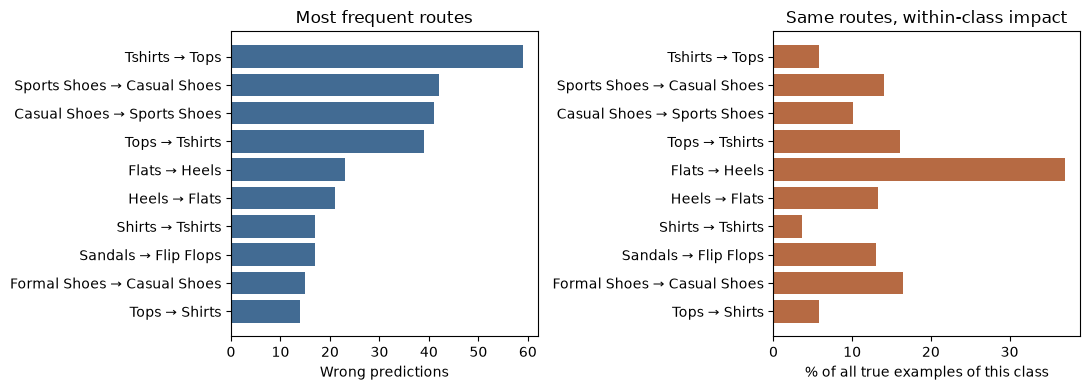

In [14]:
pairs = tables["confusion_pairs"].head(10).copy()
display(pairs.round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pair_names = pairs.articleType + " → " + pairs.predicted_label
axes[0].barh(pair_names.iloc[::-1], pairs.errors.iloc[::-1], color="#426b93")
axes[0].set(xlabel="Wrong predictions", title="Most frequent routes")
axes[1].barh(pair_names.iloc[::-1], pairs.share_of_true_class.iloc[::-1] * 100, color="#b66a43")
axes[1].set(xlabel="% of all true examples of this class", title="Same routes, within-class impact")
fig.tight_layout()
plt.show()

**Tshirts → Tops** is the largest route: 59 of 1,020 Tshirts, or 5.8%. **Flats → Heels** has fewer mistakes, 23, but those are 37.1% of all 62 Flats. A team fixing only the largest error count could overlook the much weaker boundary for Flats.

Sports Shoes and Casual Shoes also confuse each other in both directions. Their overlapping shapes are a plausible explanation, as the development examples show. These counts alone cannot prove which visual feature caused an error or whether a label itself is ambiguous. They identify where careful image and label review is useful.

This is why the final judgement needs both overall scores and class-specific failure routes. A suggestion list can soften a wrong first answer, but a human study is still needed to show that users choose correctly from it.

DeepFashion combines whole-image features with features around clothing landmarks, or key garment points. FashionNet learns categories, attributes and landmarks together [2]. Its strength is using garment detail as well as overall appearance. This is relevant to our Tshirts → Tops and Flats → Heels errors: similar categories may need finer distinctions. However, the confusion counts do not prove which features caused those mistakes. Our scratch CNN has no landmark supervision and does not reproduce FashionNet. Its richer annotations limit how directly we can adopt the method.

<a id="photos"></a>
## 9. Photo quality and robustness

**Question: does the same model cope when the same image is slightly changed?** Each condition uses the same held-out products and frozen checkpoint. The table adds the change from clean input, so a negative value means a loss. JPEG quality 85, brightness factors 0.85 and 1.15, and blur radius 1 were fixed in advance.

,condition,macro_f1,macro_f1_change,top1_accuracy,top1_change_pp
0,clean,0.5752,0.0000,0.8493,0.0000
1,jpeg_quality_85,0.5672,-0.0080,0.8475,-0.1731
2,brightness_0_85,0.3236,-0.2516,0.7096,-13.9668
3,brightness_1_15,0.4923,-0.0829,0.8171,-3.2191
4,gaussian_blur_radius_1,0.5407,-0.0345,0.8352,-1.4019


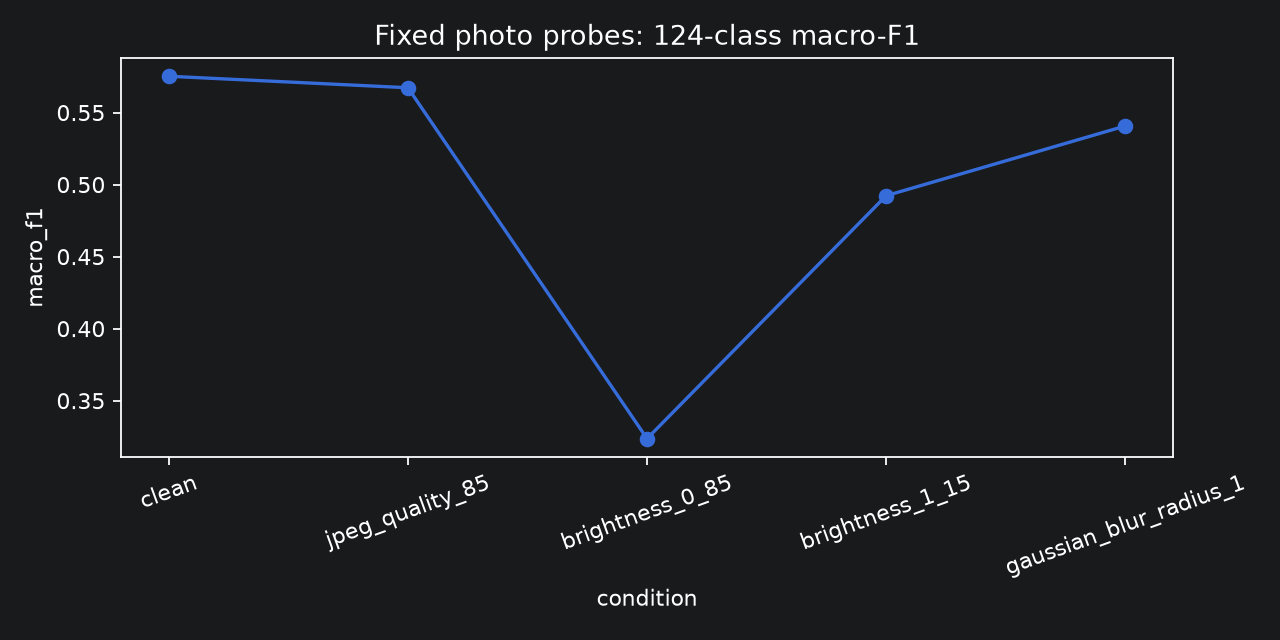

In [17]:
stress = tables["robustness"].copy()
clean = stress.loc[stress.condition.eq("clean")].iloc[0]
stress["macro_f1_change"] = stress.macro_f1 - clean.macro_f1
stress["top1_change_pp"] = 100 * (stress.top1_accuracy - clean.top1_accuracy)
display(stress[["condition", "macro_f1", "macro_f1_change", "top1_accuracy", "top1_change_pp"]].round(4))
display(Image(filename=str(PROJECT_ROOT / "results/figures/task1/final_evaluation/robustness.png")))

Multiplying brightness by 0.85 drops macro-F1 from **0.5752 to 0.3236**, a loss of 0.2516. Accuracy falls from **84.93% to 70.96%**. Brightening also hurts, with macro-F1 down to 0.4923. The model is sensitive to lighting changes in these fixed tests.

The JPEG loss is much smaller, about 0.0080 macro-F1, and blur loses about 0.0345. The problem is therefore not simply “any edit breaks the model.” Lighting deserves a specific warning. Training on consistent catalogue images may encourage dependence on those conditions, but this experiment does not identify the exact internal cause.

These paired image changes support a real robustness limit for the frozen model. They do not estimate how often customers supply dark photos, simulate all camera effects, or prove that the rejected augmented model would solve the issue. Preserve the failure in the report and test future changes on new data.

DeepFashion2 extends fashion analysis to more complex scenes through detection, landmarks, masks and matching [3]. A mask marks the pixels belonging to a garment. This helps study individual items within a scene, but hidden clothing and changes in viewpoint remain difficult. Our separate brightness test reduces macro-F1 from 0.5752 to 0.3236. Both studies make photo conditions relevant, but our lighting probe does not reproduce their occlusion tests. We have not tested customer photos or reproduced Match R-CNN. The catalogue holdout therefore supports a narrower use case than unrestricted photo recognition.

<a id="judgement"></a>
## 10. Final judgement

**The frozen plain CNN is a reasonable candidate for assisted catalogue tagging.** It should provide suggestions for a person to check, with clear limits on what has been proved. The original model choice remains based on development macro-F1; this judgement describes the later evaluation of that choice.

The case for use is concrete: **84.93%** correct first answers and **98.43%** Top-5 coverage. Same-source holdout performance does not collapse relative to pooled development OOF. Together these results make a suggestion-based demo worth building and testing with users.

The case for caution is equally concrete: **18 represented labels have zero F1**, 14 more have no true holdout examples, and darkening cuts macro-F1 to **0.3236**. These gaps do not support fully automatic labelling across all 124 categories or a claim of reliable customer-photo performance.

For the team, show one ordinary success and one meaningful failure. A later review policy needs development fitting, realistic error costs and independent testing on new labelled images. Top-5 coverage alone does not prove that a person can pick the right answer quickly. No holdout-driven retuning is part of this notebook.

<a id="export"></a>
## 11. Official export and team handoff

**Question: what exactly goes into the assignment submission?** After holdout scoring, the same checkpoint predicts the 5,829 official images. Task 1 writes `results/article_type_test_predictions.csv` with exactly `id,articleType` in template order. The teacher supplied no labels for these images, so there is no official-test accuracy claim.

Replay verifies a saved export or reports it as pending. Execution may create a missing export using the existing helper; it cannot replace a completed one. The group separately merges all targets by ID into `id,gender,articleType,season,usage`, with no blanks, preserving the teacher's original template.

In [19]:
if not (EVIDENCE_DIR / "test_prediction_receipt.json").is_file():
    if RUN_MISSING_STAGES:
        predict_test(PROJECT_ROOT)
    else:
        print("Official export pending. RUN_MISSING_STAGES=True may complete it after scoring.")
evidence = audit_final_evaluation(PROJECT_ROOT)

In [20]:
official = evidence["test_prediction_receipt"]
if official is not None:
    predictions = pd.read_csv(PROJECT_ROOT / official["output"]["path"], keep_default_na=False)
    display(pd.DataFrame([{
        "rows": len(predictions), "unique IDs": predictions.id.nunique(),
        "blank labels": int(predictions.articleType.eq("").sum()),
        "columns": ",".join(predictions.columns),
        "output": official["output"]["path"],
    }]))
    display(predictions.head())
else:
    display(Markdown("**Export remains pending.** The holdout report above is still valid."))

,rows,unique IDs,blank labels,columns,output
0,5829,5829,0,"id,articleType",results/article_type_test_predictions.csv


,id,articleType
0,52003,Casual Shoes
1,52007,Nightdress
2,52017,Bra
3,52021,Briefs
4,52023,Tshirts


Passing the export checks proves that the required rows and columns were delivered from the saved probabilities. It does not prove that all hidden test labels are correct. Keep the bundle, manifest, fixed config, required code and registry binding together when handing the model to the app team.

Task 1's completion is not the whole group's submission gate. The combined CSV still needs validation across all owners, and the shared app needs an end-to-end demonstration. Keep the current model identity and report its weaknesses rather than silently substituting a different checkpoint.

<a id="references"></a>
## 12. References

[1] Y. Cui, M. Jia, T.-Y. Lin, Y. Song, and S. Belongie, [“Class-balanced loss based on effective number of samples,”](https://openaccess.thecvf.com/content_CVPR_2019/papers/Cui_Class-Balanced_Loss_Based_on_Effective_Number_of_Samples_CVPR_2019_paper.pdf) in *Proc. IEEE/CVF Conf. Computer Vision and Pattern Recognition (CVPR)*, 2019, pp. 9268–9277.

[2] Z. Liu, P. Luo, S. Qiu, X. Wang, and X. Tang, [“DeepFashion: Powering robust clothes recognition and retrieval with rich annotations,”](https://openaccess.thecvf.com/content_cvpr_2016/html/Liu_DeepFashion_Powering_Robust_CVPR_2016_paper.html) in *Proc. IEEE Conf. Computer Vision and Pattern Recognition (CVPR)*, 2016, pp. 1096–1104.

[3] Y. Ge, R. Zhang, X. Wang, X. Tang, and P. Luo, [“DeepFashion2: A versatile benchmark for detection, pose estimation, segmentation and re-identification of clothing images,”](https://openaccess.thecvf.com/content_CVPR_2019/html/Ge_DeepFashion2_A_Versatile_Benchmark_for_Detection_Pose_Estimation_Segmentation_and_CVPR_2019_paper.html) in *Proc. IEEE/CVF Conf. Computer Vision and Pattern Recognition (CVPR)*, 2019, pp. 5337–5345.
